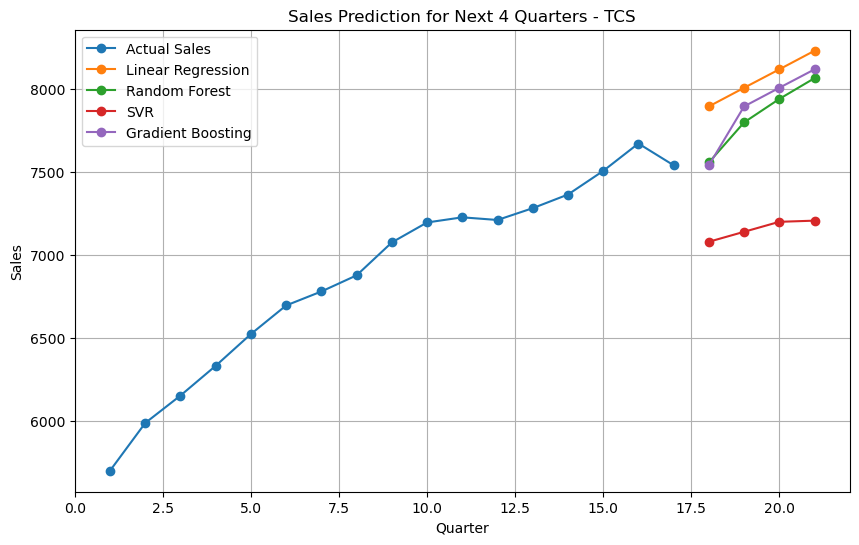


TCS Next 4 quarters predictions (rounded):
Linear Regression: [7893. 8005. 8116. 8228.]
Random Forest: [7556. 7797. 7938. 8063.]
SVR: [7079. 7139. 7199. 7206.]
Gradient Boosting: [7539. 7893. 8005. 8116.]

TCS Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: 109.35
Random Forest MAE: 37.13
SVR MAE: 469.78
Gradient Boosting MAE: 0.19

TCS Model Accuracy Metrics (R-squared):
Linear Regression R²: 0.94
Random Forest R²: 0.99
SVR R²: -0.29
Gradient Boosting R²: 1.0


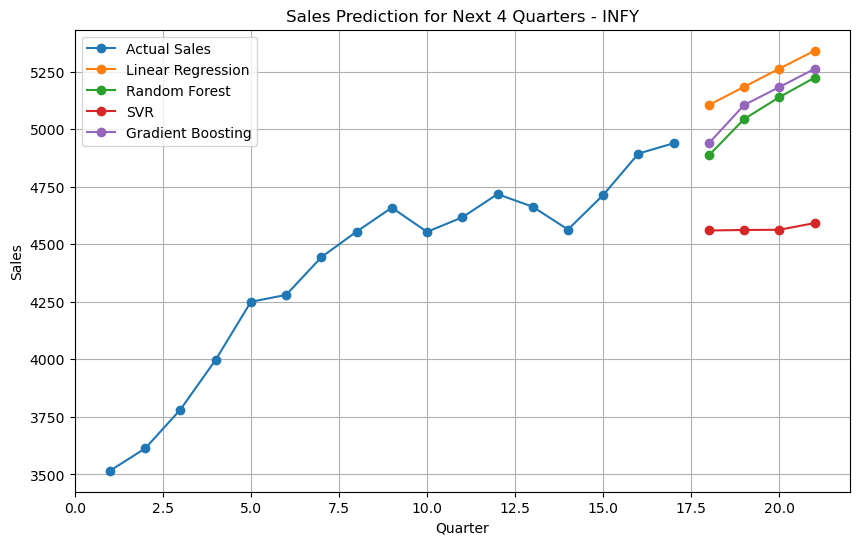


INFY Next 4 quarters predictions (rounded):
Linear Regression: [5105. 5184. 5263. 5341.]
Random Forest: [4886. 5044. 5139. 5224.]
SVR: [4560. 4562. 4563. 4592.]
Gradient Boosting: [4939. 5105. 5183. 5262.]

INFY Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: 142.4
Random Forest MAE: 32.28
SVR MAE: 314.73
Gradient Boosting MAE: 0.6

INFY Model Accuracy Metrics (R-squared):
Linear Regression R²: 0.85
Random Forest R²: 0.99
SVR R²: -0.19
Gradient Boosting R²: 1.0


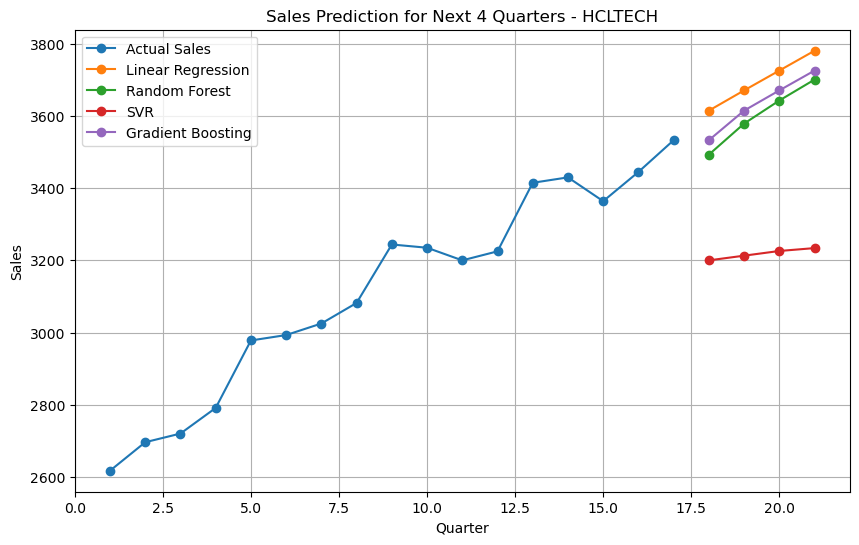


HCLTECH Next 4 quarters predictions (rounded):
Linear Regression: [3615. 3671. 3726. 3781.]
Random Forest: [3493. 3579. 3643. 3701.]
SVR: [3200. 3213. 3226. 3234.]
Gradient Boosting: [3533. 3615. 3671. 3726.]

HCLTECH Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: 54.6
Random Forest MAE: 17.22
SVR MAE: 233.19
Gradient Boosting MAE: 0.22

HCLTECH Model Accuracy Metrics (R-squared):
Linear Regression R²: 0.95
Random Forest R²: 0.99
SVR R²: -0.13
Gradient Boosting R²: 1.0


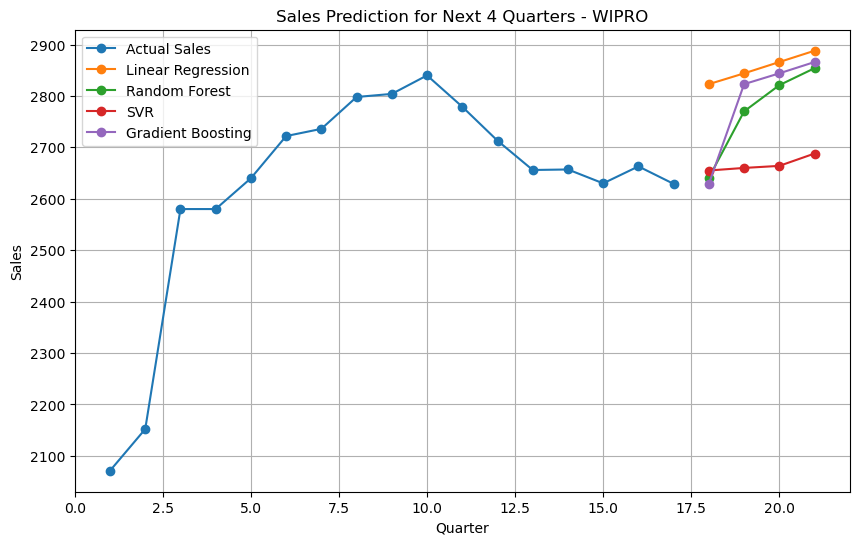


WIPRO Next 4 quarters predictions (rounded):
Linear Regression: [2823. 2844. 2866. 2888.]
Random Forest: [2641. 2770. 2821. 2854.]
SVR: [2655. 2660. 2664. 2688.]
Gradient Boosting: [2629. 2823. 2844. 2866.]

WIPRO Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: 147.54
Random Forest MAE: 27.05
SVR MAE: 127.8
Gradient Boosting MAE: 0.38

WIPRO Model Accuracy Metrics (R-squared):
Linear Regression R²: 0.28
Random Forest R²: 0.95
SVR R²: -0.08
Gradient Boosting R²: 1.0


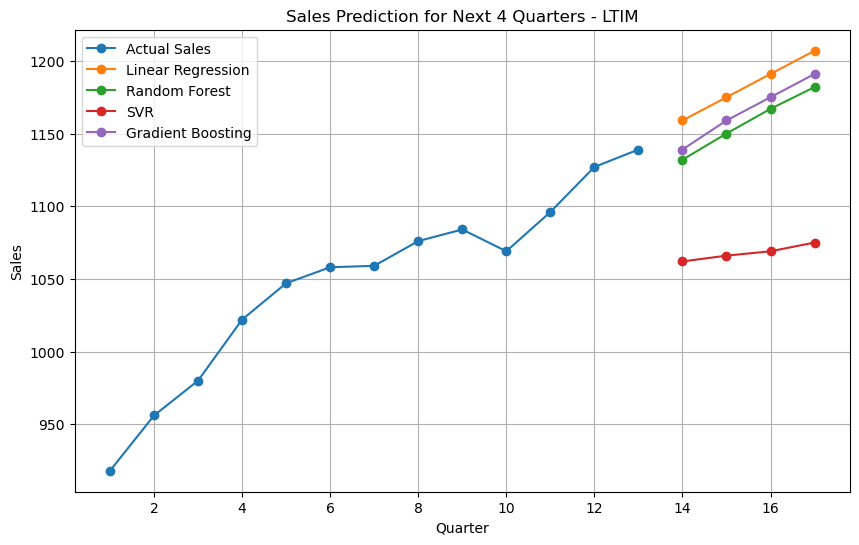


LTIM Next 4 quarters predictions (rounded):
Linear Regression: [1159. 1175. 1191. 1207.]
Random Forest: [1132. 1150. 1167. 1182.]
SVR: [1062. 1066. 1069. 1075.]
Gradient Boosting: [1139. 1159. 1175. 1191.]

LTIM Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: 15.72
Random Forest MAE: 6.22
SVR MAE: 45.17
Gradient Boosting MAE: 0.01

LTIM Model Accuracy Metrics (R-squared):
Linear Regression R²: 0.91
Random Forest R²: 0.98
SVR R²: -0.03
Gradient Boosting R²: 1.0


In [47]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Function to predict next quarters sales and plot the results
def predict_and_plot_sales(sales_data, company_name):
    if len(sales_data) == 0:
        print(f"No sales data provided for {company_name}.")
        return

    quarters = np.arange(1, len(sales_data) + 1).reshape(-1, 1)
    num_future_quarters = 4

    linear_predictions = []
    rf_predictions = []
    svr_predictions = []
    gb_predictions = []

    for _ in range(num_future_quarters):
        linear_model = LinearRegression()
        linear_model.fit(quarters, sales_data)
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(quarters, sales_data)
        svr_model = SVR(kernel='rbf')
        svr_model.fit(quarters, sales_data)
        gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
        gb_model.fit(quarters, sales_data)

        next_quarter = len(sales_data) + 1
        linear_prediction = linear_model.predict(np.array([[next_quarter]])).round()[0]
        rf_prediction = rf_model.predict(np.array([[next_quarter]])).round()[0]
        svr_prediction = svr_model.predict(np.array([[next_quarter]])).round()[0]
        gb_prediction = gb_model.predict(np.array([[next_quarter]])).round()[0]

        linear_predictions.append(linear_prediction)
        rf_predictions.append(rf_prediction)
        svr_predictions.append(svr_prediction)
        gb_predictions.append(gb_prediction)

        sales_data = np.append(sales_data, [linear_prediction])
        quarters = np.arange(1, len(sales_data) + 1).reshape(-1, 1)

    linear_mae = round(mean_absolute_error(sales_data[:-num_future_quarters], linear_model.predict(quarters[:-num_future_quarters])), 2)
    rf_mae = round(mean_absolute_error(sales_data[:-num_future_quarters], rf_model.predict(quarters[:-num_future_quarters])), 2)
    svr_mae = round(mean_absolute_error(sales_data[:-num_future_quarters], svr_model.predict(quarters[:-num_future_quarters])), 2)
    gb_mae = round(mean_absolute_error(sales_data[:-num_future_quarters], gb_model.predict(quarters[:-num_future_quarters])), 2)

    linear_r2 = round(r2_score(sales_data[:-num_future_quarters], linear_model.predict(quarters[:-num_future_quarters])), 2)
    rf_r2 = round(r2_score(sales_data[:-num_future_quarters], rf_model.predict(quarters[:-num_future_quarters])), 2)
    svr_r2 = round(r2_score(sales_data[:-num_future_quarters], svr_model.predict(quarters[:-num_future_quarters])), 2)
    gb_r2 = round(r2_score(sales_data[:-num_future_quarters], gb_model.predict(quarters[:-num_future_quarters])), 2)

    linear_predictions = np.array(linear_predictions)
    rf_predictions = np.array(rf_predictions)
    svr_predictions = np.array(svr_predictions)
    gb_predictions = np.array(gb_predictions)

    plt.figure(figsize=(10, 6))
    plt.plot(quarters[:len(quarters)-num_future_quarters], sales_data[:len(sales_data)-num_future_quarters], label='Actual Sales', marker='o')
    plt.plot(np.arange(len(sales_data) - num_future_quarters + 1, len(sales_data) + 1), linear_predictions, label='Linear Regression', marker='o')
    plt.plot(np.arange(len(sales_data) - num_future_quarters + 1, len(sales_data) + 1), rf_predictions, label='Random Forest', marker='o')
    plt.plot(np.arange(len(sales_data) - num_future_quarters + 1, len(sales_data) + 1), svr_predictions, label='SVR', marker='o')
    plt.plot(np.arange(len(sales_data) - num_future_quarters + 1, len(sales_data) + 1), gb_predictions, label='Gradient Boosting', marker='o')
    plt.xlabel('Quarter')
    plt.ylabel('Sales')
    plt.title(f'Sales Prediction for Next 4 Quarters - {company_name}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\n{company_name} Next 4 quarters predictions (rounded):")
    print(f"Linear Regression: {linear_predictions}")
    print(f"Random Forest: {rf_predictions}")
    print(f"SVR: {svr_predictions}")
    print(f"Gradient Boosting: {gb_predictions}")

    print(f"\n{company_name} Model Accuracy Metrics (Mean Absolute Error):")
    print(f"Linear Regression MAE: {linear_mae}")
    print(f"Random Forest MAE: {rf_mae}")
    print(f"SVR MAE: {svr_mae}")
    print(f"Gradient Boosting MAE: {gb_mae}")

    print(f"\n{company_name} Model Accuracy Metrics (R-squared):")
    print(f"Linear Regression R²: {linear_r2}")
    print(f"Random Forest R²: {rf_r2}")
    print(f"SVR R²: {svr_r2}")
    print(f"Gradient Boosting R²: {gb_r2}")

# Sales data for multiple companies
sales1 = [5702, 5989, 6154, 6333, 6524, 6696, 6780, 6877, 7075, 7195, 7226, 7210, 7281, 7363, 7505, 7670, 7539]
sales2 = [3516, 3613, 3782, 3998, 4250, 4280, 4444, 4555, 4659, 4554, 4617, 4718, 4663, 4564, 4714, 4894, 4939]
sales3 = [2617, 2696, 2720, 2791, 2978, 2993, 3025, 3082, 3244, 3235, 3200, 3225, 3415, 3430, 3364, 3445, 3533]
sales4 = [2071, 2152, 2580, 2580, 2640, 2722, 2736, 2798, 2804, 2840, 2779, 2713, 2656, 2657, 2630, 2663, 2629]
sales5 = [918, 956, 980, 1022, 1047, 1058, 1059, 1076, 1084, 1069, 1096, 1127, 1139]

# Predict and plot for each company
predict_and_plot_sales(np.array(sales1), "TCS")
predict_and_plot_sales(np.array(sales2), "INFY")
predict_and_plot_sales(np.array(sales3), "HCLTECH")
predict_and_plot_sales(np.array(sales4), "WIPRO")
predict_and_plot_sales(np.array(sales5), "LTIM")


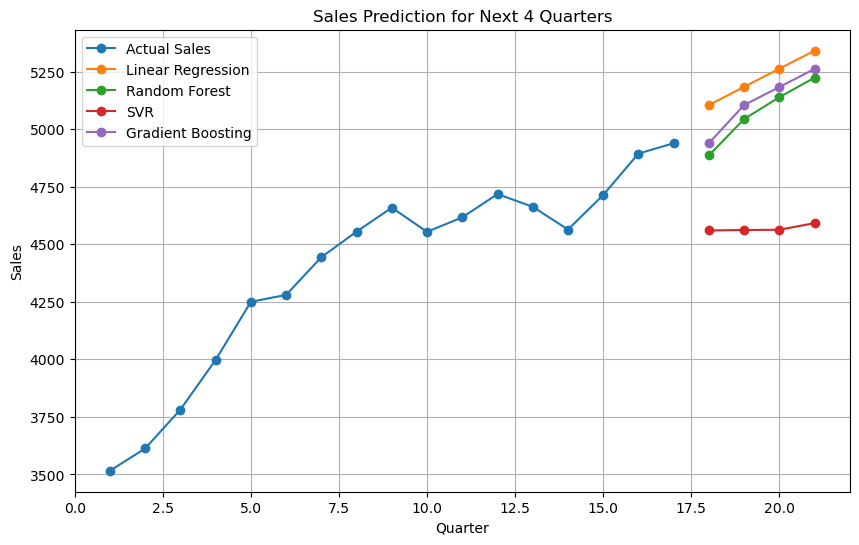

Next 4 quarters predictions (rounded):
Linear Regression: [5105. 5184. 5263. 5341.]
Random Forest: [4886. 5044. 5139. 5224.]
SVR: [4560. 4562. 4563. 4592.]
Gradient Boosting: [4939. 5105. 5183. 5262.]

Model Accuracy Metrics (Mean Absolute Error):
Linear Regression MAE: [142.4, 134.5, 127.42, 121.07]
Random Forest MAE: [33.23, 33.16, 32.34, 32.14]
SVR MAE: [309.75, 322.36, 338.12, 356.19]
Gradient Boosting MAE: [0.33, 0.46, 0.48, 0.56]

Model Accuracy Metrics (R-squared):
Linear Regression R²: [0.85, 0.87, 0.89, 0.9]
Random Forest R²: [0.99, 0.99, 0.99, 0.99]
SVR R²: [-0.13, -0.06, -0.02, -0.01]
Gradient Boosting R²: [1.0, 1.0, 1.0, 1.0]


In [45]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Quarterly sales data (example input)
# INFY sales = np.array([3516, 3613, 3782, 3998, 4250, 4280, 4444, 4555, 4659, 4554, 4617, 4718, 4663, 4564, 4714, 4894, 4939])
# TCC
sales = np.array([2617, 2696, 2720, 2791, 2978, 2993, 3025, 3082, 3244, 3235, 3200, 3225, 3415, 3430, 3364, 3445, 3533])
quarters = np.arange(1, len(sales) + 1).reshape(-1, 1)

# Define the number of future quarters to predict
num_future_quarters = 4

# Initialize predictions and accuracy metrics for each model
linear_predictions = []
rf_predictions = []
svr_predictions = []
gb_predictions = []

linear_mae = []
rf_mae = []
svr_mae = []
gb_mae = []

linear_r2 = []
rf_r2 = []
svr_r2 = []
gb_r2 = []

# Predict one quarter at a time for all models
for _ in range(num_future_quarters):
    # Fit the models with the current sales data
    linear_model = LinearRegression()
    linear_model.fit(quarters, sales)
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(quarters, sales)
    svr_model = SVR(kernel='rbf')
    svr_model.fit(quarters, sales)
    gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb_model.fit(quarters, sales)
    
    # Predict the next quarter
    next_quarter = len(sales) + 1
    linear_prediction = linear_model.predict(np.array([[next_quarter]])).round()[0]
    rf_prediction = rf_model.predict(np.array([[next_quarter]])).round()[0]
    svr_prediction = svr_model.predict(np.array([[next_quarter]])).round()[0]
    gb_prediction = gb_model.predict(np.array([[next_quarter]])).round()[0]
    
    # Append predictions to the respective lists
    linear_predictions.append(linear_prediction)
    rf_predictions.append(rf_prediction)
    svr_predictions.append(svr_prediction)
    gb_predictions.append(gb_prediction)
    
    # Update sales data with the new prediction
    sales = np.append(sales, [linear_prediction])
    quarters = np.arange(1, len(sales) + 1).reshape(-1, 1)
    
    # Calculate accuracy metrics
    linear_mae.append(round(mean_absolute_error(sales[:-1], linear_model.predict(quarters[:-1])), 2))
    rf_mae.append(round(mean_absolute_error(sales[:-1], rf_model.predict(quarters[:-1])), 2))
    svr_mae.append(round(mean_absolute_error(sales[:-1], svr_model.predict(quarters[:-1])), 2))
    gb_mae.append(round(mean_absolute_error(sales[:-1], gb_model.predict(quarters[:-1])), 2))
    
    linear_r2.append(round(r2_score(sales[:-1], linear_model.predict(quarters[:-1])), 2))
    rf_r2.append(round(r2_score(sales[:-1], rf_model.predict(quarters[:-1])), 2))
    svr_r2.append(round(r2_score(sales[:-1], svr_model.predict(quarters[:-1])), 2))
    gb_r2.append(round(r2_score(sales[:-1], gb_model.predict(quarters[:-1])), 2))

# Convert lists to numpy arrays for plotting
linear_predictions = np.array(linear_predictions)
rf_predictions = np.array(rf_predictions)
svr_predictions = np.array(svr_predictions)
gb_predictions = np.array(gb_predictions)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(quarters[:len(quarters)-num_future_quarters], sales[:len(sales)-num_future_quarters], label='Actual Sales', marker='o')
plt.plot(np.arange(len(sales) - num_future_quarters + 1, len(sales) + 1), linear_predictions, label='Linear Regression', marker='o')
plt.plot(np.arange(len(sales) - num_future_quarters + 1, len(sales) + 1), rf_predictions, label='Random Forest', marker='o')
plt.plot(np.arange(len(sales) - num_future_quarters + 1, len(sales) + 1), svr_predictions, label='SVR', marker='o')
plt.plot(np.arange(len(sales) - num_future_quarters + 1, len(sales) + 1), gb_predictions, label='Gradient Boosting', marker='o')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.title('Sales Prediction for Next 4 Quarters')
plt.legend()
plt.grid(True)
plt.show()

# Print predictions and accuracy metrics
print("Next 4 quarters predictions (rounded):")
print(f"Linear Regression: {linear_predictions}")
print(f"Random Forest: {rf_predictions}")
print(f"SVR: {svr_predictions}")
print(f"Gradient Boosting: {gb_predictions}")

print("\nModel Accuracy Metrics (Mean Absolute Error):")
print(f"Linear Regression MAE: {linear_mae}")
print(f"Random Forest MAE: {rf_mae}")
print(f"SVR MAE: {svr_mae}")
print(f"Gradient Boosting MAE: {gb_mae}")

print("\nModel Accuracy Metrics (R-squared):")
print(f"Linear Regression R²: {linear_r2}")
print(f"Random Forest R²: {rf_r2}")
print(f"SVR R²: {svr_r2}")
print(f"Gradient Boosting R²: {gb_r2}")
